# **🚁 VisDrone Aerial Object Detection with YOLOv8**
In this lab, we will:
✅ **Use YOLOv8** for **aerial object detection from drones**  
✅ **Understand the VisDrone dataset structure**  
✅ **Train a YOLOv8 model**  
✅ **Evaluate the model on the validation set**  
✅ **Run inference on test images**  

---

## **1️⃣ Understanding the Dataset Structure**
The VisDrone dataset follows the **YOLO format**, which consists of:
📂 **train/** → Training images & labels  
📂 **valid/** → Validation images & labels  
📂 **test/** → Test images (for inference)  
📜 **data.yaml** → Defines dataset paths & class names  

VisDrone is captured by **drone-mounted cameras** across many cities, environments, and densities — perfect for learning detection on **small, crowded objects** seen from above. ✈️

### **🔹 YOLO Dataset Folder Structure**
```
VisDrone/
│── train/
│   │── images/
│   │   ├── 0000001.jpg
│   │   ├── 0000002.jpg
│   │   ├── ...
│   │── labels/
│   │   ├── 0000001.txt
│   │   ├── 0000002.txt
│   │   ├── ...
│
│── valid/
│   │── images/
│   │   ├── ...
│   │── labels/
│   │   ├── ...
│
│── test/
│   │── images/
│   │   ├── ...
│   │── labels/
│   │   ├── ...
│
│── data.yaml
```
Each **image** has a **corresponding label** file with the **same name**, but a `.txt` extension.

---

## **2️⃣ What's Inside a YOLO Label File?**
Each `.txt` file contains **annotations** in this format:

```
<class_id> <x_center> <y_center> <width> <height>
```

✅ **All values are normalized** between **0 and 1**  
✅ The **bounding box** is defined by its **center** and **size**  

### **🔹 Example (`0000001.txt`)**
```
3 0.512 0.604 0.045 0.038
0 0.318 0.221 0.012 0.029
```
- **First column** → Class ID (`3` = car, `0` = pedestrian)  
- **Rest** → Bounding box (normalized)  

### **🔹 VisDrone Classes (10 total)**
| ID | Class | ID | Class |
|----|-------|----|-------|
| 0 | pedestrian | 5 | truck |
| 1 | people | 6 | tricycle |
| 2 | bicycle | 7 | awning-tricycle |
| 3 | car | 8 | bus |
| 4 | van | 9 | motor |

> 💡 **Heads up:** VisDrone objects are **tiny and densely packed** (think cars and people seen from 100m up), so this is a tougher challenge than ground-level detection!

---

## **3️⃣ Loading the Dataset**

In [ ]:
# # Please uncomment this out when you are running this lab on google colab!
# import os

# # Set KaggleHub cache to a directory inside /content/
# os.environ["KAGGLEHUB_CACHE"] = "/content/data"

In [ ]:
import kagglehub
import os

datasets_directory = os.path.abspath(os.path.join(".", "..","..", "Datasets"))
os.environ["KAGGLEHUB_CACHE"] = datasets_directory

# Download the dataset
path = kagglehub.dataset_download("banuprasadb/visdrone-dataset")
print(path)

path =os.path.join(path,"VisDrone_Dataset")
print("Path to dataset files:", path)

In [6]:
# Explore what's inside the downloaded dataset folder
import os

for root, dirs, files in os.walk(path):
    depth = root.replace(path, "").count(os.sep)
    indent = "    " * depth
    print(f"{indent}📂 {os.path.basename(root)}/")
    if files:
        print(f"{indent}    ({len(files)} files, e.g. {files[0]})")
    # Don't print every single image file — just go 2 levels deep
    if depth >= 2:
        dirs[:] = []

📂 VisDrone_Dataset/
    (1 files, e.g. visdrone.yaml)
    📂 VisDrone2019-DET-test-challenge/
        📂 images/
            (1580 files, e.g. 0000000_00098_d_0000001.jpg)
    📂 VisDrone2019-DET-test-dev/
        📂 images/
            (1610 files, e.g. 0000006_00159_d_0000001.jpg)
        📂 labels/
            (1610 files, e.g. 0000006_00159_d_0000001.txt)
    📂 VisDrone2019-DET-train/
        (1 files, e.g. labels.cache)
        📂 images/
            (6471 files, e.g. 0000002_00005_d_0000014.jpg)
        📂 labels/
            (6471 files, e.g. 0000002_00005_d_0000014.txt)
    📂 VisDrone2019-DET-val/
        (1 files, e.g. labels.cache)
        📂 images/
            (548 files, e.g. 0000001_02999_d_0000005.jpg)
        📂 labels/
            (548 files, e.g. 0000001_02999_d_0000005.txt)


In [ ]:
# Locate the data.yaml file (its exact path can vary by dataset version)
import glob

yaml_path = os.path.join(path , "visdrone.yaml")
print(" YAML file path:", yaml_path)


print("\nUsing:", path)

# Check dataset information
print("\n--- visdrone.yaml contents ---")
print(open(yaml_path).read())

> 🛠️ **Note:** Kaggle datasets sometimes ship a `data.yaml` with **absolute paths** that won't match your machine. If training can't find the images, open the YAML and fix the `train:` / `val:` / `test:` paths so they point to the actual image folders inside `path`. The cell below does this automatically.

In [8]:
import os
import yaml

# 1. Ensure this points directly to your original data.yaml file
root_dir = os.path.dirname(os.path.abspath(yaml_path))

# 2. Read the existing config
with open(yaml_path, "r") as f:
    data_cfg = yaml.safe_load(f)

# 3. Fix the main path
data_cfg["path"] = root_dir

# 4. Swap forward slashes to backslashes for the splits
for split in ["train", "val", "test"]:
    if split in data_cfg and isinstance(data_cfg[split], str):
        data_cfg[split] = data_cfg[split].replace("/", "\\")

with open(yaml_path, "w") as f:
    yaml.safe_dump(data_cfg, f, sort_keys=False)

print("✅ Patched data_fixed.yaml:")
print(open(yaml_path).read())

✅ Patched data_fixed.yaml:
path: c:\Users\Raghad\Desktop\Summer Training\Datasets\datasets\banuprasadb\visdrone-dataset\versions\1\VisDrone_Dataset
train: VisDrone2019-DET-train\images
val: VisDrone2019-DET-val\images
test: VisDrone2019-DET-test-dev\images
nc: 10
names:
  0: pedestrian
  1: people
  2: bicycle
  3: car
  4: van
  5: truck
  6: tricycle
  7: awning-tricycle
  8: bus
  9: motor



## **4️⃣ Training a YOLOv8 Model**
We will fine-tune a **pretrained YOLOv8 model**.

In [9]:
# Install Ultralytics library which has Yolo
!pip install -q ultralytics

In [10]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
# Load YOLOv8 model (small version)
model = YOLO("yolov8s.pt")

#### Let's try to predict an image before training

In [ ]:
import glob

# Grab the first test image (filenames in VisDrone are not fixed, so glob it)
test_images = sorted(glob.glob(os.path.join(root_dir, "VisDrone2019-DET-test-dev", "images", "*.jpg")))
sample_image = test_images[0]
print("Sample image:", sample_image)

# Run inference with the *untrained* (COCO-pretrained) model
results = model(sample_image, save=True)

# Convert result to a NumPy array and display
predicted_image = results[0].plot()  # Convert prediction to an image

plt.figure(figsize=(16, 16))
plt.imshow(predicted_image)
plt.axis("off")
plt.title("Predicted Image (before training)")
plt.show()

## Hmm, COCO knows 'car' and 'person'... but it has no idea what a *tricycle* or *awning-tricycle* is from the sky. 🚁😅
#### Those tiny aerial objects need a model that's actually seen drone footage.

#### Let's train it! 🚀

In [ ]:
# Train on the VisDrone dataset
# VisDrone is large & objects are tiny — feel free to bump epochs higher if you have GPU time.
model.train(
    data    =  str(yaml_path), 
    epochs  =  10, 
    imgsz   =  640,
    batch   =  16,
    )

## **5️⃣ Evaluating the Model**
We use **mAP@0.5:0.95** to assess performance.

> 📉 **Don't panic if mAP looks low!** VisDrone is a **notoriously hard benchmark** — objects are minuscule and heavily occluded. Even strong published models land in the ~0.25–0.40 mAP range. Relative improvement is what matters here.

In [ ]:
# Run validation
metrics = model.val(data=yaml_path)

## **6️⃣ Running Inference on Test Images**


In [ ]:
# Load an image and run inference
model = YOLO(model.trainer.best)  # Use the best weights
results = model(sample_image, save=True)

# Convert result to a NumPy array and display
predicted_image = results[0].plot()  # Convert prediction to an image

plt.figure(figsize=(8, 8))
plt.imshow(predicted_image)
plt.axis("off")
plt.title("Predicted Image (after training)")
plt.show()

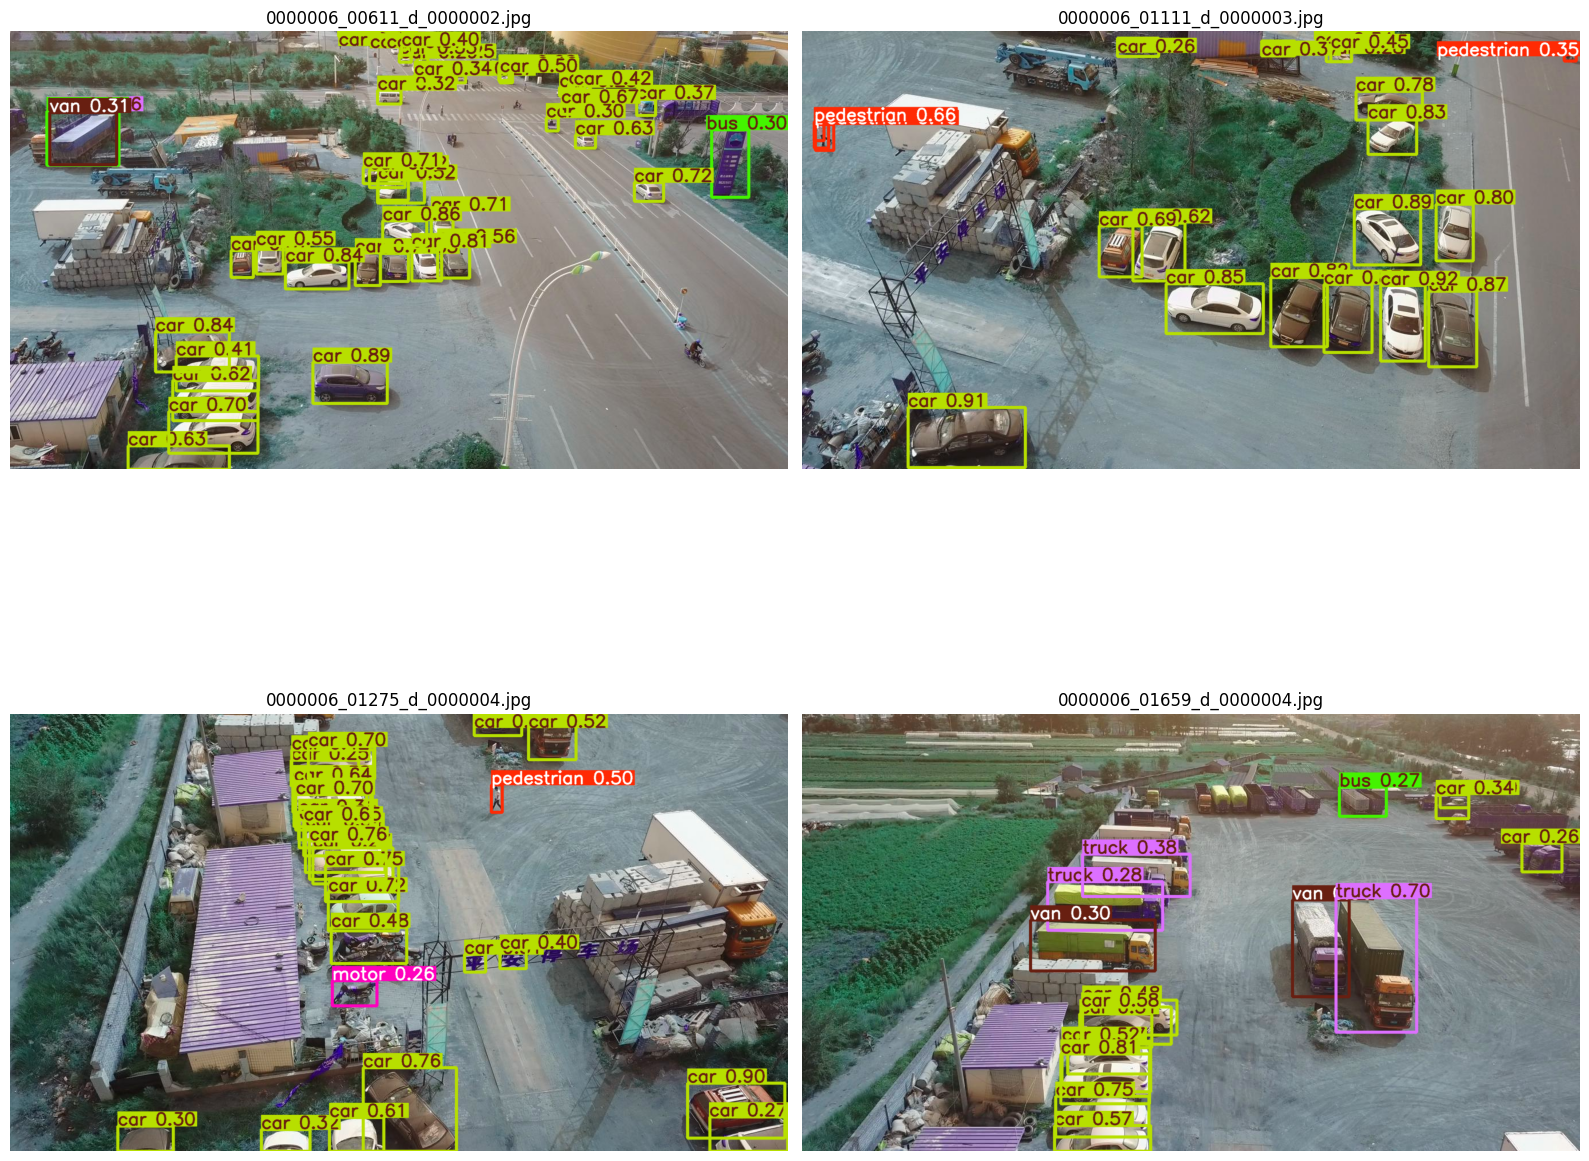

In [74]:
# Let's look at a few more test images side-by-side to see how it does on crowded scenes
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

for ax, img_path in zip(axes.ravel(), test_images[1:5]):
    res = model(img_path, verbose=False)
    ax.imshow(res[0].plot())
    ax.axis("off")
    ax.set_title(os.path.basename(img_path))

plt.tight_layout()
plt.show()